In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

df = pd.read_csv('plrx.txt', delimiter='\t', header=None)
X = df.iloc[:, :12]
y = df.iloc[:, 12]

feature_names = [f'c{i+1}' for i in range(12)]
X.columns = feature_names

class_1 = X[y == 1.0]  # Relaxed
class_2 = X[y == 2.0]  # Planning

### Feature engineering

In [11]:
def hjorth_params(row):
    row = np.asarray(row, dtype=float)
    d1 = np.diff(row)
    d2 = np.diff(d1)
    var0, var1, var2 = np.var(row), np.var(d1), np.var(d2)
    activity = var0
    mobility = np.sqrt(var1 / var0) if var0 > 0 else 0.0
    complexity = (np.sqrt(var2 / var1) / mobility) if (var1 > 0 and mobility > 0) else 0.0
    return activity, mobility, complexity

def katz_fd(row):
    row = np.asarray(row, dtype=float)
    n = len(row) - 1
    L = np.sum(np.sqrt(np.diff(row) ** 2 + 1))
    d = np.max(np.sqrt((np.arange(1, len(row))) ** 2 + (row[1:] - row[0]) ** 2))
    if L == 0 or d == 0:
        return 0.0
    return np.log10(n) / (np.log10(d / L) + np.log10(n))

eng_features = X.apply(
    lambda row: pd.Series(
        {**dict(zip(['hjorth_activity', 'hjorth_mobility', 'hjorth_complexity'], hjorth_params(row))),
        'katz_fd': katz_fd(row)}
    ),
    axis=1
)

X_eng = pd.concat([X, eng_features], axis=1)
X_eng.head()

,c1,c2,c3,c4,c5,c6,c7,c8,c9,c10,c11,c12,hjorth_activity,hjorth_mobility,hjorth_complexity,katz_fd
0,-0.17936,-0.20700,-0.209710,-0.097260,-0.119210,-0.17322,-0.280760,0.223170,0.418660,-0.032886,0.003383,-0.334250,0.042331,1.170131,1.275784,1.011541
1,-0.14659,-0.16494,0.249870,-0.073985,0.494940,-0.15633,-0.288910,0.500800,-0.045553,0.050759,-0.017511,0.066959,0.059279,1.743326,1.079981,1.034230
2,-0.13131,0.51816,0.432810,0.397890,0.043127,0.56320,-0.013246,-0.062833,-0.883390,-0.040303,0.088057,0.631200,0.162019,1.254355,1.314821,1.047318
3,0.64940,0.41878,0.148350,0.333490,-0.219740,0.39891,0.590650,0.077100,-1.107200,-0.367230,0.364680,0.571720,0.235432,1.191728,1.232746,1.059826
4,-0.40628,0.11503,0.073336,0.070066,-0.030920,0.15205,-0.191420,-0.580430,-0.102250,0.153750,-0.126950,0.184570,0.052572,1.331197,1.134159,1.018542


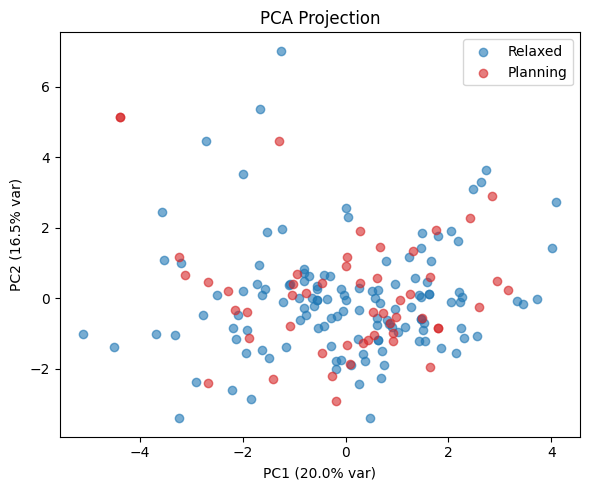

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_scaled = StandardScaler().fit_transform(X_eng)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
for label, name, color in [(1.0, 'Relaxed', 'tab:blue'), (2.0, 'Planning', 'tab:red')]:
    mask = y == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=name, alpha=0.6, color=color)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA Projection')
plt.legend()
plt.tight_layout()
plt.show()

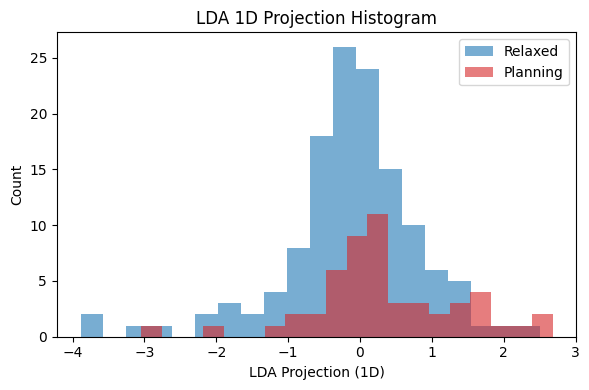

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_viz = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda_viz.fit_transform(X_scaled, y)

plt.figure(figsize=(6, 4))
for label, name, color in [(1.0, 'Relaxed', 'tab:blue'), (2.0, 'Planning', 'tab:red')]:
    mask = y == label
    plt.hist(X_lda[mask, 0], bins=20, alpha=0.6, label=name, color=color)
plt.xlabel('LDA Projection (1D)')
plt.ylabel('Count')
plt.title('LDA 1D Projection Histogram')
plt.legend()
plt.tight_layout()
plt.show()

--- 5-Fold CV Performance (LDA + SMOTE) ---
Accuracy  : 0.4287 (± 0.0384)
Precision : 0.6297 (± 0.0298)
Recall    : 0.4923 (± 0.0955)
F1        : 0.5466 (± 0.0634)
Roc_auc   : 0.3645 (± 0.0449)


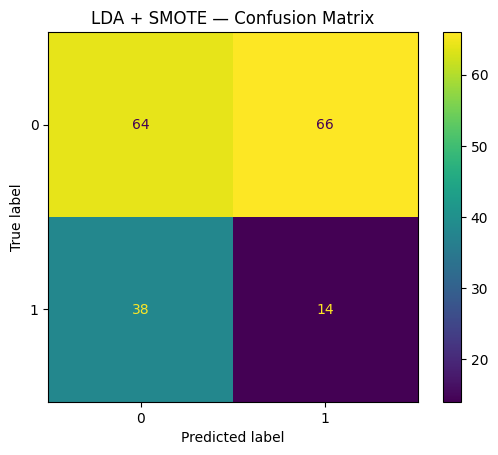

              precision    recall  f1-score   support

         1.0       0.63      0.49      0.55       130
         2.0       0.17      0.27      0.21        52

    accuracy                           0.43       182
   macro avg       0.40      0.38      0.38       182
weighted avg       0.50      0.43      0.45       182



In [14]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

lda_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LinearDiscriminantAnalysis())
])

lda_scores = cross_validate(lda_pipe, X_eng, y, cv=cv, scoring=scoring)
print("--- 5-Fold CV Performance (LDA + SMOTE) ---")
for metric in scoring:
    vals = lda_scores[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {vals.mean():.4f} (± {vals.std():.4f})")

y_pred_lda = cross_val_predict(lda_pipe, X_eng, y, cv=cv)
ConfusionMatrixDisplay(confusion_matrix(y, y_pred_lda)).plot()
plt.title('LDA + SMOTE — Confusion Matrix')
plt.show()
print(classification_report(y, y_pred_lda))

--- 5-Fold Nested CV Performance (SVM + SMOTE + GridSearch) ---
Accuracy  : 0.5781 (± 0.1193)
Precision : 0.6970 (± 0.0547)
Recall    : 0.7000 (± 0.1811)
F1        : 0.6920 (± 0.1144)
Roc_auc   : 0.4572 (± 0.0848)


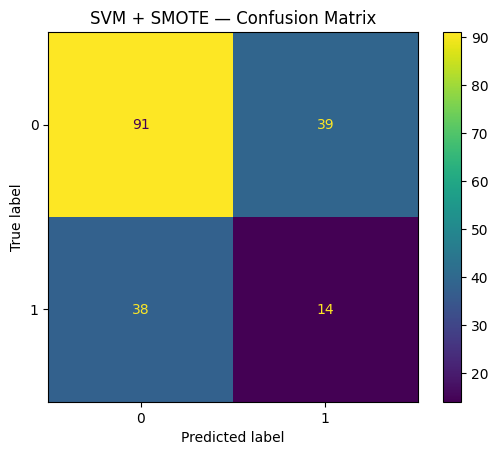

              precision    recall  f1-score   support

         1.0       0.71      0.70      0.70       130
         2.0       0.26      0.27      0.27        52

    accuracy                           0.58       182
   macro avg       0.48      0.48      0.48       182
weighted avg       0.58      0.58      0.58       182

Best params on full data: {'clf__C': 10, 'clf__gamma': 1, 'clf__kernel': 'rbf'}


In [15]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', SVC())
])

svm_param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': [1, 0.1, 0.01, 0.001],
    'clf__kernel': ['rbf', 'poly']
}

# Inner loop tunes hyperparameters; outer loop reports unbiased performance (nested CV)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_grid = GridSearchCV(svm_pipe, svm_param_grid, scoring='roc_auc', cv=inner_cv, n_jobs=-1)

svm_scores = cross_validate(svm_grid, X_eng, y, cv=outer_cv, scoring=scoring, n_jobs=-1)
print("--- 5-Fold Nested CV Performance (SVM + SMOTE + GridSearch) ---")
for metric in scoring:
    vals = svm_scores[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {vals.mean():.4f} (± {vals.std():.4f})")

y_pred_svm = cross_val_predict(svm_grid, X_eng, y, cv=outer_cv, n_jobs=-1)
ConfusionMatrixDisplay(confusion_matrix(y, y_pred_svm)).plot()
plt.title('SVM + SMOTE — Confusion Matrix')
plt.show()
print(classification_report(y, y_pred_svm))

# fit on full data once, just to see which params get picked most often (informational only)
svm_grid.fit(X_eng, y)
print("Best params on full data:", svm_grid.best_params_)

--- 5-Fold Nested CV Performance (KNN + SMOTE + GridSearch) ---
Accuracy  : 0.5336 (± 0.0790)
Precision : 0.7621 (± 0.0688)
Recall    : 0.5000 (± 0.1167)
F1        : 0.5980 (± 0.0963)
Roc_auc   : 0.5140 (± 0.0584)


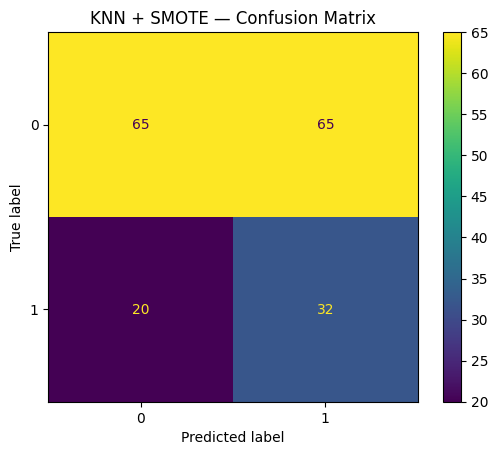

              precision    recall  f1-score   support

         1.0       0.76      0.50      0.60       130
         2.0       0.33      0.62      0.43        52

    accuracy                           0.53       182
   macro avg       0.55      0.56      0.52       182
weighted avg       0.64      0.53      0.55       182

Best params on full data: {'clf__n_neighbors': 3, 'clf__p': 2, 'clf__weights': 'distance'}


In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', KNeighborsClassifier())
])

knn_param_grid = {
    'clf__n_neighbors': [3, 5, 7, 9, 11, 15],
    'clf__weights': ['uniform', 'distance'],
    'clf__p': [1, 2]  # Manhattan vs Euclidean
}

knn_grid = GridSearchCV(knn_pipe, knn_param_grid, scoring='roc_auc', cv=inner_cv, n_jobs=-1)

knn_scores = cross_validate(knn_grid, X_eng, y, cv=outer_cv, scoring=scoring, n_jobs=-1)
print("--- 5-Fold Nested CV Performance (KNN + SMOTE + GridSearch) ---")
for metric in scoring:
    vals = knn_scores[f'test_{metric}']
    print(f"{metric.capitalize():10s}: {vals.mean():.4f} (± {vals.std():.4f})")

y_pred_knn = cross_val_predict(knn_grid, X_eng, y, cv=outer_cv, n_jobs=-1)
ConfusionMatrixDisplay(confusion_matrix(y, y_pred_knn)).plot()
plt.title('KNN + SMOTE — Confusion Matrix')
plt.show()
print(classification_report(y, y_pred_knn))

knn_grid.fit(X_eng, y)
print("Best params on full data:", knn_grid.best_params_)